
# MODELO DE PREDICCIÓN DEL CRECIMIENTO EN LA POBLACIÓN ESTUDIANTIL DE LA UPEA

# Notebook 1: Preparación y Exploración de Datos

Fecha: Agosto 2025
Descripción: Generación y preparación de datos para modelado predictivo

In [1]:
# ============================================================================
# INSTALACIÓN DE LIBRERÍAS REQUERIDAS
# ============================================================================

#import sys
#!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn statsmodels plotly

# ============================================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [3]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [110]:
# ============================================================================
# DATASETS MATRICULACIONES UPEA
# ============================================================================
#df_matricula_regin = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/maestria_sigloXX_proyeccciones/matriculados_regin_carrera.csv",sep=';', encoding='latin1')
df_matricula_regin = pd.read_csv("matriculados_regin_carrera.csv",sep=';', encoding='latin1')
df_matricula_regin_filtered = df_matricula_regin[(df_matricula_regin['año_y'] >= 2005) & (df_matricula_regin['año_y'] <= 2015)]

#df_matricula_base = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/maestria_sigloXX_proyeccciones/matriculados_base_upea_carrera.csv",sep=';', encoding='latin1')
df_matricula_base = pd.read_csv("matriculados_base_upea_carrera.csv",sep=';', encoding='latin1')
df_matricula_base_filtered = df_matricula_base[(df_matricula_base['año_y'] >= 2016) & (df_matricula_base['año_y'] <= 2025)]

df_carreras = pd.concat([df_matricula_regin_filtered, df_matricula_base_filtered], ignore_index=True)

# Limpiar nombres de columnas (eliminar espacios)
df_carreras.columns = df_carreras.columns.str.strip()
df_carreras=df_carreras.rename(columns={'año_y': 'gestion'})
#df_carreras=df_carreras.rename(columns={'matricula_carrera': 'matricula_total'})
df_carreras['semestre'] = df_carreras['periodo'].astype(str).str.split('-').str[1]

# Convertir 'fecha' a datetime y 'gestion' a int
df_carreras['fecha'] = pd.to_datetime(df_carreras['fecha'])
df_carreras['gestion'] = df_carreras['gestion'].astype(int)

# Crear columna con la suma por 'gestion' y 'carrera'
df_carreras['suma_por_anio_carrera'] = df_carreras.groupby(['gestion', 'carrera_academica'])['matricula_carrera'].transform('sum')
df_carreras=df_carreras.rename(columns={'suma_por_anio_carrera': 'matricula_total'})

df_carreras.head()
df_carreras.info()


<class 'pandas.DataFrame'>
RangeIndex: 1295 entries, 0 to 1294
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              1295 non-null   datetime64[us]
 1   matricula_carrera  1295 non-null   int64         
 2   carrera_academica  1295 non-null   str           
 3   periodo            1295 non-null   str           
 4   gestion            1295 non-null   int64         
 5   porcentaje         575 non-null    float64       
 6   semestre           1295 non-null   object        
 7   matricula_total    1295 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(3), object(1), str(2)
memory usage: 81.1+ KB


In [120]:
# Ver todos los registros de MEDICINA
carrera_df = df_carreras[df_carreras['carrera_academica'] == 'DERECHO']
carrera_df.info()


<class 'pandas.DataFrame'>
Index: 42 entries, 4 to 1263
Data columns (total 17 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   fecha                                          42 non-null     datetime64[us]
 1   matricula_carrera                              42 non-null     int64         
 2   carrera_academica                              42 non-null     str           
 3   periodo                                        42 non-null     str           
 4   gestion                                        42 non-null     int64         
 5   porcentaje                                     22 non-null     float64       
 6   semestre                                       42 non-null     object        
 7   matricula_total                                42 non-null     int64         
 8   pib_departamental_millones_bs                  40 non-null     float64      

In [112]:

#por carrera 
#df_matricula=carrera_df

In [121]:

# Combinar todos los datos de carreras 
df_investigados = pd.read_csv("datos_investigacion.csv",sep=';')
# Limpiar nombres de columnas (eliminar espacios)
df_carreras.columns = df_carreras.columns.str.strip()
df_investigados.columns = df_investigados.columns.str.strip()

df_carreras = df_carreras.merge(df_investigados, on=['gestion'], how='left')
df_carreras.info()

<class 'pandas.DataFrame'>
RangeIndex: 1295 entries, 0 to 1294
Data columns (total 26 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   fecha                                            1295 non-null   datetime64[us]
 1   matricula_carrera                                1295 non-null   int64         
 2   carrera_academica                                1295 non-null   str           
 3   periodo                                          1295 non-null   str           
 4   gestion                                          1295 non-null   int64         
 5   porcentaje                                       575 non-null    float64       
 6   semestre                                         1295 non-null   object        
 7   matricula_total                                  1295 non-null   int64         
 8   pib_departamental_millones_bs_x                  

In [114]:
# ============================================================================
# DATASETS CONCLOMERADOS
# ============================================================================
df_matricula = pd.read_csv("datos_historicos_matriculados_upea_Xperiodo.csv",sep=';')
df_matricula = df_matricula[(df_matricula['gestion'] >= 2005) & (df_matricula['gestion'] <= 2025)]



#df_investigados = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/maestria_sigloXX_proyeccciones/datos_investigacion.csv",sep=';')
df_investigados = pd.read_csv("datos_investigacion.csv",sep=';')

# Limpiar nombres de columnas (eliminar espacios)
df_matricula.columns = df_matricula.columns.str.strip()
df_investigados.columns = df_investigados.columns.str.strip()

# Combinar todos los datos
df_completo = df_matricula.merge(df_investigados, on=['gestion'], how='left')

#conversion limpieza de comas
#DataFrame se llama df
columnas_a_convertir = [
    'pib_departamental_millones_bs',
    'poblacion_bolivia',
    'poblacion_lapaz',
    'matricula secundaria de 1ro a 6to',
    '5to fue 15% de matriculados',
    'graduados_secundaria'
]

#for col in columnas_a_convertir:
    #if col in df_completo.columns:
        # Convertir a string primero, luego limpiar y convertir a numérico
        #df_completo[col] = df_completo[col].astype(str).str.replace(',', '').str.replace(' ', '').str.replace('.', '')
        #df_completo[col] = pd.to_numeric(df_completo[col], errors='coerce')


#df_areas = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/maestria_sigloXX_proyeccciones/datos_historicos_area_matriculados_Parea.csv")
df_areas = pd.read_csv("datos_historicos_area_matriculados_Parea.csv")

print("✅ Datos generados correctamente")
print(f"📊 Registros principales: {len(df_matricula)}")
print(f"📊 Registros por área: {len(df_areas)}")
print(f"📊 Registros por carrera: {len(df_carreras)}")
print(f"📊 Registros de factores externos: {len(df_investigados)}")
df_completo.info()


✅ Datos generados correctamente
📊 Registros principales: 42
📊 Registros por área: 482
📊 Registros por carrera: 1295
📊 Registros de factores externos: 25
<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 16 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   fecha                                          42 non-null     str    
 1   matricula_total                                42 non-null     int64  
 2   ano_x                                          42 non-null     int64  
 3   ano_y                                          42 non-null     int64  
 4   semestre                                       42 non-null     str    
 5   periodo                                        42 non-null     str    
 6   gestion                                        42 non-null     int64  
 7   pib_departamental_millones_bs                  40 non-null     flo

In [115]:
# ============================================================================
# EXPLORACIÓN INICIAL DE DATOS
# ============================================================================

print("\n" + "="*60)
print("📈 EXPLORACIÓN INICIAL DE DATOS")
print("="*60)

# Información general
print("\n🔍 Información general del dataset:")
print(df_completo.info())

print("\n📋 Primeros 5 registros:")
print(df_completo.head())

print("\n📊 Estadísticas descriptivas:")
print(df_completo[['matricula_total', 'pib_departamental_millones_bs',
                   'poblacion_el_alto', 'graduados_secundaria']].describe())

# Cálculo de tasas de crecimiento
df_completo['tasa_crecimiento'] = df_completo['matricula_total'].pct_change() * 100
df_completo['tasa_crecimiento_anual'] = df_completo['matricula_total'].pct_change(periods=2) * 100

print(f"\n📈 Tasa de crecimiento promedio semestral: {df_completo['tasa_crecimiento'].mean():.2f}%")
print(f"📈 Tasa de crecimiento promedio anual: {df_completo['tasa_crecimiento_anual'].mean():.2f}%")



📈 EXPLORACIÓN INICIAL DE DATOS

🔍 Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 16 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   fecha                                          42 non-null     str    
 1   matricula_total                                42 non-null     int64  
 2   ano_x                                          42 non-null     int64  
 3   ano_y                                          42 non-null     int64  
 4   semestre                                       42 non-null     str    
 5   periodo                                        42 non-null     str    
 6   gestion                                        42 non-null     int64  
 7   pib_departamental_millones_bs                  40 non-null     float64
 8   poblacion_bolivia                              40 non-null     float64
 9  


📊 VISUALIZACIONES EXPLORATORIAS


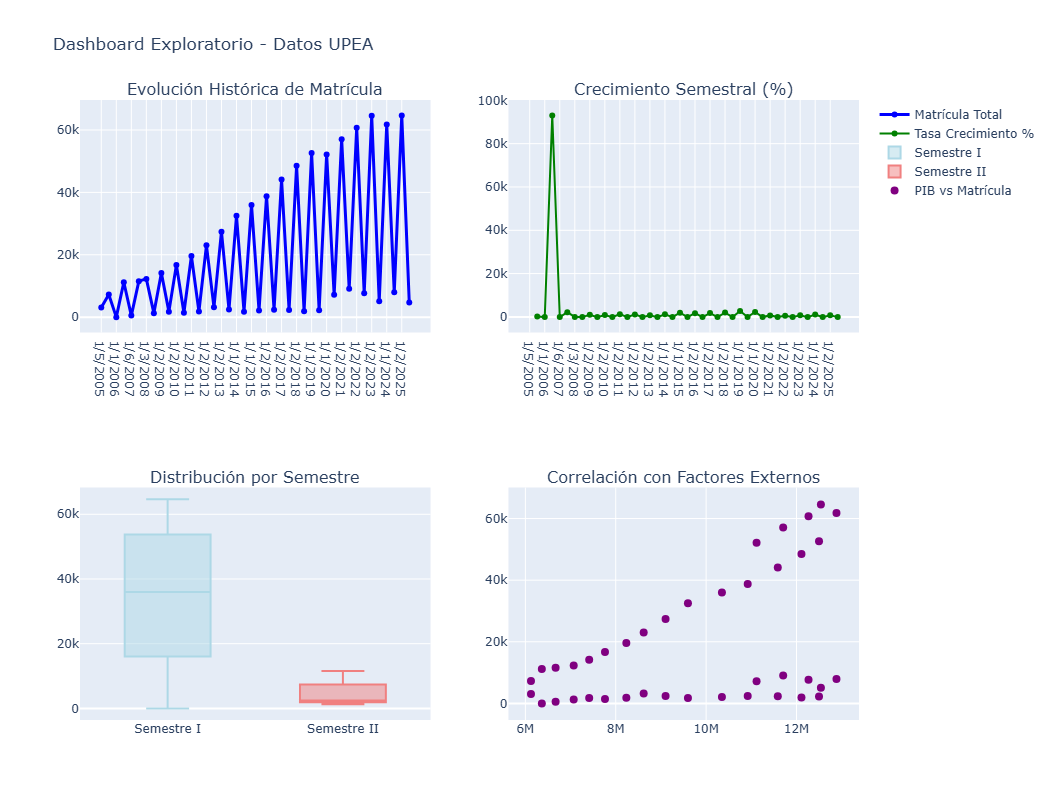

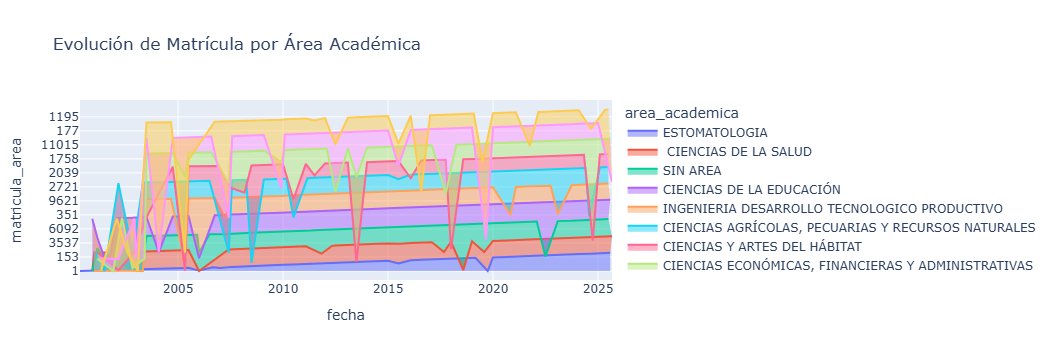

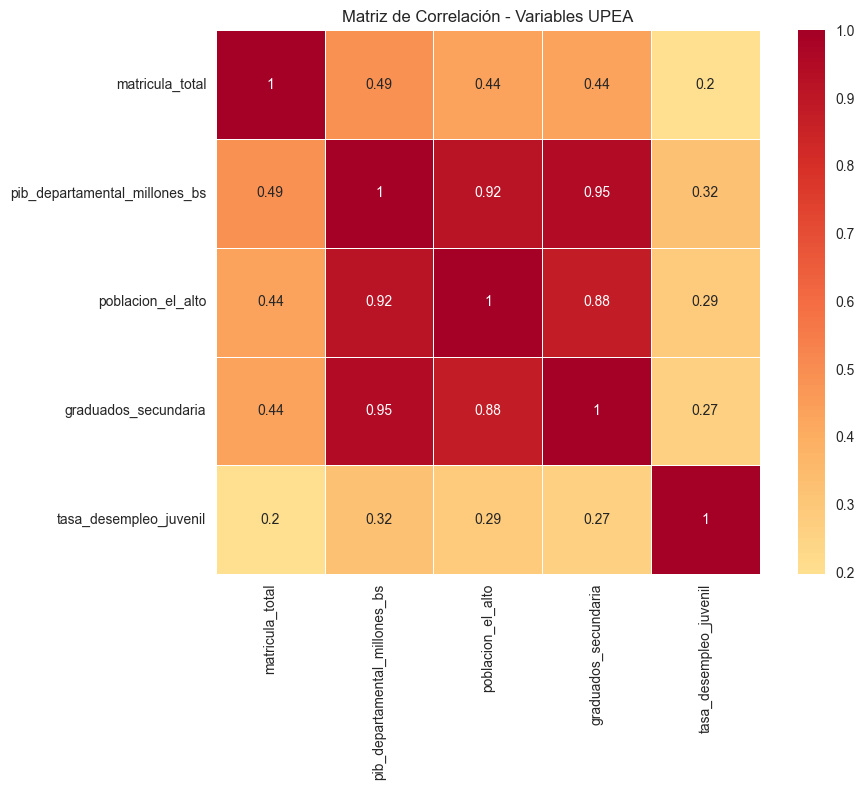

In [116]:

# ============================================================================
# VISUALIZACIONES EXPLORATORIAS
# ============================================================================

print("\n" + "="*60)
print("📊 VISUALIZACIONES EXPLORATORIAS")
print("="*60)

# 1. Evolución histórica de la matrícula
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Evolución Histórica de Matrícula',
                   'Crecimiento Semestral (%)',
                   'Distribución por Semestre',
                   'Correlación con Factores Externos'),
    specs=[[{"secondary_y": False}, {"secondary_y": False}],
           [{"secondary_y": False}, {"secondary_y": False}]]
)

# Gráfico 1: Evolución histórica
fig.add_trace(
    go.Scatter(x=df_completo['fecha'],
               y=df_completo['matricula_total'],
               mode='lines+markers',
               name='Matrícula Total',
               line=dict(color='blue', width=3)),
    row=1, col=1
)

# Gráfico 2: Tasa de crecimiento
fig.add_trace(
    go.Scatter(x=df_completo['fecha'],
               y=df_completo['tasa_crecimiento'],
               mode='lines+markers',
               name='Tasa Crecimiento %',
               line=dict(color='green', width=2)),
    row=1, col=2
)

# Gráfico 3: Box plot por semestre
semestre_I = df_completo[df_completo['semestre'] == 'I']['matricula_total']
semestre_II = df_completo[df_completo['semestre'] == 'II']['matricula_total']

fig.add_trace(
    go.Box(y=semestre_I, name='Semestre I',
           marker_color='lightblue'),
    row=2, col=1
)

fig.add_trace(
    go.Box(y=semestre_II, name='Semestre II',
           marker_color='lightcoral'),
    row=2, col=1
)

# Gráfico 4: Correlación con PIB
fig.add_trace(
    go.Scatter(x=df_completo['pib_departamental_millones_bs'],
               y=df_completo['matricula_total'],
               mode='markers',
               name='PIB vs Matrícula',
               marker=dict(size=8, color='purple')),
    row=2, col=2
)

fig.update_layout(height=800, showlegend=True,
                  title_text="Dashboard Exploratorio - Datos UPEA")
fig.show()

# 2. Distribución por áreas académicas
fig_areas = px.area(df_areas,
                   x='fecha',
                   y='matricula_area',
                   color='area_academica',
                   title='Evolución de Matrícula por Área Académica')
fig_areas.show()

# 3. Matriz de correlación
columnas_numericas = ['matricula_total', 'pib_departamental_millones_bs',
                     'poblacion_el_alto', 'graduados_secundaria', 'tasa_desempleo_juvenil']
matriz_corr = df_completo[columnas_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='RdYlBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación - Variables UPEA')
plt.tight_layout()
plt.show()


In [117]:

# ============================================================================
# ANÁLISIS DE ESTACIONALIDAD Y TENDENCIAS
# ============================================================================

print("\n" + "="*60)
print("📈 ANÁLISIS DE ESTACIONALIDAD Y TENDENCIAS")
print("="*60)

# Descomposición estacional manual
df_completo['año_numero'] = df_completo['gestion'] - 2010
df_completo['semestre_numero'] = df_completo['semestre'].map({'I': 1, 'II': 0})

# Análisis por semestre
analisis_semestre = df_completo.groupby('semestre')['matricula_total'].agg([
    'mean', 'std', 'min', 'max', 'count'
]).round(0)

print("📊 Análisis por semestre:")
print(analisis_semestre)

# Diferencia estacional
diferencia_estacional = analisis_semestre.loc['I', 'mean'] - analisis_semestre.loc['II', 'mean']
porcentaje_diferencia = (diferencia_estacional / analisis_semestre.loc['II', 'mean']) * 100

print(f"\n🔍 Diferencia estacional:")
print(f"   Semestre I vs II: +{diferencia_estacional:.0f} estudiantes ({porcentaje_diferencia:.1f}%)")

# Tendencia por año
tendencia_anual = df_completo.groupby('gestion')['matricula_total'].mean().reset_index()
tendencia_anual['crecimiento_anual'] = tendencia_anual['matricula_total'].pct_change() * 100

print(f"\n📈 Crecimiento promedio anual: {tendencia_anual['crecimiento_anual'].mean():.2f}%")
print(f"📈 Máximo crecimiento anual: {tendencia_anual['crecimiento_anual'].max():.2f}%")
print(f"📉 Mínimo crecimiento anual: {tendencia_anual['crecimiento_anual'].min():.2f}%")



📈 ANÁLISIS DE ESTACIONALIDAD Y TENDENCIAS
📊 Análisis por semestre:
             mean      std   min    max  count
semestre                                      
I         34773.0  21987.0    12  64684     21
II         4582.0   3370.0  1292  11545     21

🔍 Diferencia estacional:
   Semestre I vs II: +30191 estudiantes (658.9%)

📈 Crecimiento promedio anual: 10.13%
📈 Máximo crecimiento anual: 22.28%
📉 Mínimo crecimiento anual: -0.56%


In [118]:
df_carreras

,fecha,matricula_carrera,carrera_academica,periodo,gestion,porcentaje,semestre,matricula_total,pib_departamental_millones_bs,poblacion_bolivia,poblacion_lapaz,poblacion_el_alto,matricula secundaria de 1ro a 6to,5to fue 15% de matriculados,promedio de tasa termino bruto 6to secundaria,graduados_secundaria,tasa_desempleo_juvenil
0,2005-05-01,35,INGENIERÍA ELECTRÓNICA,2005-I,2005,0.34,I,180,6124302.0,8911754.0,2479509.0,722279.0,108405.0,16261.0,82.0,13331.0,5226.0
1,2005-05-01,60,SOCIOLOGÍA,2005-I,2005,0.58,I,122,6124302.0,8911754.0,2479509.0,722279.0,108405.0,16261.0,82.0,13331.0,5226.0
2,2005-05-01,8,ARQUITECTURA,2005-I,2005,0.08,I,189,6124302.0,8911754.0,2479509.0,722279.0,108405.0,16261.0,82.0,13331.0,5226.0
3,2005-05-01,681,ENFERMERÍA,2005-I,2005,6.58,I,696,6124302.0,8911754.0,2479509.0,722279.0,108405.0,16261.0,82.0,13331.0,5226.0
4,2005-05-01,1344,DERECHO,2005-I,2005,13.00,I,1508,6124302.0,8911754.0,2479509.0,722279.0,108405.0,16261.0,82.0,13331.0,5226.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1290,2025-11-01,126,PSICOMOTRICIDAD Y DEPORTES,2025-II,2025,NaN,II,1280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1291,2025-11-01,254,PSICOLOGÍA,2025-II,2025,NaN,II,1568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1292,2025-12-01,260,INGENIERÍA DE SISTEMAS,2025-II,2025,NaN,II,4062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1293,2025-12-01,13,CIENCIAS POLITICAS,2025-II,2025,NaN,II,611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [119]:
# ============================================================================
# PREPARACIÓN DE DATOS PARA MODELADO CARRERAS
# ============================================================================

print("\n" + "="*60)
print("🔧 PREPARACIÓN DE DATOS PARA MODELADO CARRERAS")
print("="*60)


# Crear características adicionales para ML
df_ml_car = df_carreras.copy()

# Descomposición estacional manual
df_ml_car['semestre_numero'] = df_ml_car['semestre'].map({'I': 1, 'II': 0})


# Variables temporales
df_ml_car['año_numero'] = df_ml_car['gestion'] - 2010
df_ml_car['semestre_dummy'] = df_ml_car['semestre'].map({'I': 1, 'II': 0})
df_ml_car['periodo_numero'] = range(len(df_ml_car))

# Variables lag (valores previos)
df_ml_car['matricula_lag1'] = df_ml_car['matricula_total'].shift(1)
df_ml_car['matricula_lag2'] = df_ml_car['matricula_total'].shift(2)
df_ml_car['matricula_lag4'] = df_ml_car['matricula_total'].shift(4)  # Año anterior

# Medias móviles
df_ml_car['media_movil_4'] = df_ml_car['matricula_total'].rolling(window=4).mean()
df_ml_car['media_movil_8'] = df_ml_car['matricula_total'].rolling(window=8).mean()

# Variables derivadas
df_ml_car['crecimiento_poblacional'] = df_ml_car['poblacion_el_alto'].pct_change()
df_ml_car['ratio_graduados_poblacion'] = df_ml_car['graduados_secundaria'] / df_ml['poblacion_el_alto'] * 1000

# Eliminar filas con NaN para modelado
df_ml_car = df_ml_car.dropna()

print(f"✅ Dataset preparado para ML:")
print(f"   Registros para ML carreras: {len(df_ml_car)}")
print(f"   Variables carreras: {len(df_ml_car.columns)}")
df_ml_car


🔧 PREPARACIÓN DE DATOS PARA MODELADO CARRERAS
✅ Dataset preparado para ML:
   Registros para ML carreras: 33
   Variables carreras: 28


,fecha,matricula_carrera,carrera_academica,periodo,gestion,porcentaje,semestre,matricula_total,pib_departamental_millones_bs,poblacion_bolivia,...,año_numero,semestre_dummy,periodo_numero,matricula_lag1,matricula_lag2,matricula_lag4,media_movil_4,media_movil_8,crecimiento_poblacional,ratio_graduados_poblacion
7,2005-05-01,13,INGENIERÍA CIVIL,2005-I,2005,0.13,I,173,6124302.0,8911754.0,...,-5,1,7,155.0,73.0,696.0,477.25,387.000,0.0,17.167642
8,2005-05-01,34,INGENIERÍA DE SISTEMAS,2005-I,2005,0.33,I,605,6124302.0,8911754.0,...,-5,1,8,173.0,155.0,1508.0,251.50,440.125,0.0,16.777016
9,2005-05-01,73,ODONTOLOGÍA,2005-I,2005,0.71,I,677,6124302.0,8911754.0,...,-5,1,9,605.0,173.0,73.0,402.50,509.500,0.0,16.777016
10,2005-05-01,112,MEDICINA VETERINARIA Y ZOOTECNIA,2005-I,2005,1.08,I,328,6124302.0,8911754.0,...,-5,1,10,677.0,605.0,155.0,445.75,526.875,0.0,16.403751
11,2005-05-01,231,ADMINISTRACIÓN DE EMPRESAS,2005-I,2005,2.23,I,296,6124302.0,8911754.0,...,-5,1,11,328.0,677.0,173.0,476.50,476.875,0.0,16.403751
12,2005-05-01,162,TRABAJO SOCIAL,2005-I,2005,1.57,I,327,6124302.0,8911754.0,...,-5,1,12,296.0,328.0,605.0,407.00,329.250,0.0,16.046752
13,2005-05-01,120,ECONOMÍA,2005-I,2005,1.16,I,169,6124302.0,8911754.0,...,-5,1,13,327.0,296.0,677.0,280.00,341.250,0.0,16.046752
14,2005-05-01,439,CONTADURÍA PÚBLICA,2005-I,2005,4.24,I,466,6124302.0,8911754.0,...,-5,1,14,169.0,327.0,328.0,314.50,380.125,0.0,15.704962
15,2005-05-01,156,INGENIERÍA AGRONÓMICA,2005-I,2005,1.51,I,346,6124302.0,8911754.0,...,-5,1,15,466.0,169.0,296.0,327.00,401.750,0.0,15.704962
16,2005-06-01,196,MEDICINA,2005-I,2005,1.90,I,629,6124302.0,8911754.0,...,-5,1,16,346.0,466.0,327.0,402.50,404.750,0.0,15.648146


In [96]:

# ============================================================================
# PREPARACIÓN DE DATOS PARA MODELADO
# ============================================================================

print("\n" + "="*60)
print("🔧 PREPARACIÓN DE DATOS PARA MODELADO")
print("="*60)

# Crear características adicionales para ML
df_ml = df_completo.copy()

# Variables temporales
df_ml['año_numero'] = df_ml['gestion'] - 2010
df_ml['semestre_dummy'] = df_ml['semestre'].map({'I': 1, 'II': 0})
df_ml['periodo_numero'] = range(len(df_ml))

# Variables lag (valores previos)
df_ml['matricula_lag1'] = df_ml['matricula_total'].shift(1)
df_ml['matricula_lag2'] = df_ml['matricula_total'].shift(2)
df_ml['matricula_lag4'] = df_ml['matricula_total'].shift(4)  # Año anterior

# Medias móviles
df_ml['media_movil_4'] = df_ml['matricula_total'].rolling(window=4).mean()
df_ml['media_movil_8'] = df_ml['matricula_total'].rolling(window=8).mean()

# Variables derivadas
df_ml['crecimiento_poblacional'] = df_ml['poblacion_el_alto'].pct_change()
df_ml['ratio_graduados_poblacion'] = df_ml['graduados_secundaria'] / df_ml['poblacion_el_alto'] * 1000

# Eliminar filas con NaN para modelado
df_ml_limpio = df_ml.dropna()

print(f"✅ Dataset preparado para ML:")
print(f"   Registros originales: {len(df_completo)}")
print(f"   Registros para ML: {len(df_ml_limpio)}")
print(f"   Variables: {len(df_ml_limpio.columns)}")

# Guardar datasets procesados
print("\n💾 Guardando datasets...")

# Guardar en formato pickle para mantener tipos de datos
df_completo.to_pickle('datos_upea_completos.pkl')
df_ml_limpio.to_pickle('datos_upea_ml.pkl')
df_carreras.to_pickle('datos_upea_carreras.pkl')
df_ml_car.to_pickle('datos_upea_carreras_ml.pkl')
df_areas.to_pickle('datos_upea_areas.pkl')

# También en CSV para compatibilidad
df_completo.to_csv('datos_upea_completos.csv', index=False)
df_ml_limpio.to_csv('datos_upea_ml.csv', index=False)
df_areas.to_csv('datos_upea_areas.csv', index=False)

print("✅ Datasets guardados correctamente")

# ============================================================================
# RESUMEN FINAL
# ============================================================================

print("\n" + "="*60)
print("📋 RESUMEN DE DATOS GENERADOS")
print("="*60)

resumen = {
    'Período': f"{df_completo['gestion'].min()} - {df_completo['gestion'].max()}",
    'Semestres': len(df_completo),
    'Matrícula inicial': f"{df_completo['matricula_total'].iloc[0]:,}",
    'Matrícula final': f"{df_completo['matricula_total'].iloc[-1]:,}",
    'Crecimiento total': f"{((df_completo['matricula_total'].iloc[-1] / df_completo['matricula_total'].iloc[0]) - 1) * 100:.1f}%",
    'Tasa anual promedio': f"{df_completo['tasa_crecimiento_anual'].mean():.2f}%",
    'Áreas académicas': len(df_areas['area_academica'].unique()),
    'Variables ML': len(df_ml_limpio.columns)
}

for clave, valor in resumen.items():
    print(f"   {clave}: {valor}")

print("\n🎯 Los datos están listos para el modelado predictivo!")
print("📁 Archivos generados:")
print("   - datos_upea_completos.pkl/csv")
print("   - datos_upea_ml.pkl/csv")
print("   - datos_upea_areas.pkl/csv")



🔧 PREPARACIÓN DE DATOS PARA MODELADO
✅ Dataset preparado para ML:
   Registros originales: 42
   Registros para ML: 33
   Variables: 29

💾 Guardando datasets...
✅ Datasets guardados correctamente

📋 RESUMEN DE DATOS GENERADOS
   Período: 2005 - 2025
   Semestres: 42
   Matrícula inicial: 3,075
   Matrícula final: 4,670
   Crecimiento total: 51.9%
   Tasa anual promedio: 170.79%
   Áreas académicas: 11
   Variables ML: 29

🎯 Los datos están listos para el modelado predictivo!
📁 Archivos generados:
   - datos_upea_completos.pkl/csv
   - datos_upea_ml.pkl/csv
   - datos_upea_areas.pkl/csv
